Que 1. The delivery_time.csv dataset contains information about Delivery time and Sorting Time. We have to prepare linear regression model to predict Sorting time on the basis of Delivery Time. Also evaluate the model by using evaluation metrics. Do proper EDA & visualize the result.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df1 = pd.read_csv('E:\\PGCP -BDA\\Machine_Learning\\Assignments\\Datasets\\delivery_time.csv')
df1.head()

,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [3]:
df1.tail()

,Delivery Time,Sorting Time
16,13.75,6
17,18.11,7
18,8.00,2
19,17.83,7
20,21.50,5


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Delivery Time  21 non-null     float64
 1   Sorting Time   21 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 464.0 bytes


In [5]:
df1.isna().sum()

Delivery Time    0
Sorting Time     0
dtype: int64

In [6]:
df1.describe()

,Delivery Time,Sorting Time
count,21.000000,21.000000
mean,16.790952,6.190476
std,5.074901,2.542028
min,8.000000,2.000000
25%,13.500000,4.000000
50%,17.830000,6.000000
75%,19.750000,8.000000
max,29.000000,10.000000


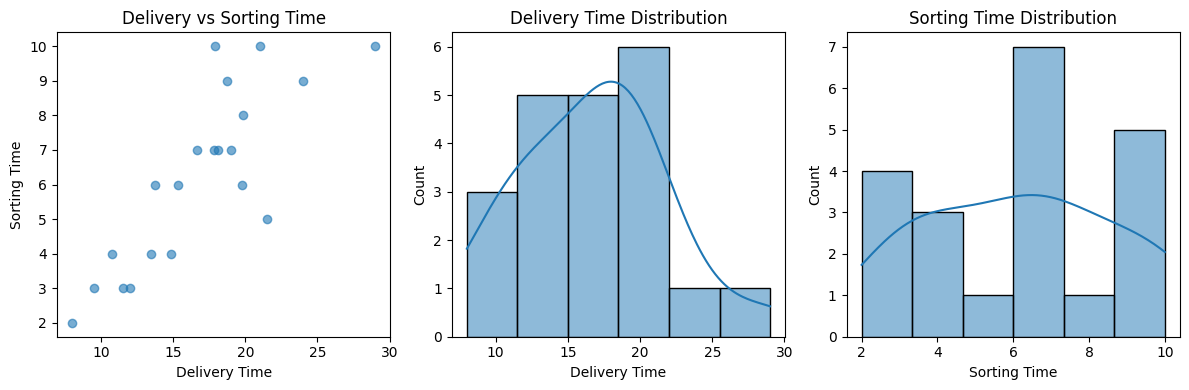

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(df1['Delivery Time'], df1['Sorting Time'], alpha=0.6)
plt.xlabel('Delivery Time')
plt.ylabel('Sorting Time')
plt.title('Delivery vs Sorting Time')

plt.subplot(1,3,2)
sns.histplot(df1['Delivery Time'], kde=True)
plt.title('Delivery Time Distribution')

plt.subplot(1,3,3)
sns.histplot(df1['Sorting Time'], kde=True)
plt.title('Sorting Time Distribution')

plt.tight_layout()
plt.show()

In [8]:
corr1 = df1['Delivery Time'].corr(df1['Sorting Time'])
print(f'Correlation: {corr1:.3f}')

Correlation: 0.826


In [9]:
X1 = df1[['Delivery Time']]
y1 = df1['Sorting Time']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [10]:
model1 = LinearRegression()
model1.fit(X1_train, y1_train)

print(f'Intercept: {model1.intercept_:.3f}')
print(f'Coefficient: {model1.coef_[0]:.3f}')
print(f'Equation: Sorting Time = {model1.intercept_:.3f} + {model1.coef_[0]:.3f} * Delivery Time')

Intercept: -0.329
Coefficient: 0.375
Equation: Sorting Time = -0.329 + 0.375 * Delivery Time


In [11]:
y1_pred_train = model1.predict(X1_train)
y1_pred_test = model1.predict(X1_test)

print('Training Set Performance:')
print(f'R²: {r2_score(y1_train, y1_pred_train):.4f}')
print(f'MAE: {mean_absolute_error(y1_train, y1_pred_train):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y1_train, y1_pred_train)):.4f}')

print('\nTesting Set Performance:')
print(f'R²: {r2_score(y1_test, y1_pred_test):.4f}')
print(f'MAE: {mean_absolute_error(y1_test, y1_pred_test):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred_test)):.4f}')

Training Set Performance:
R²: 0.7595
MAE: 0.9313
RMSE: 1.1561

Testing Set Performance:
R²: 0.4041
MAE: 1.7173
RMSE: 2.0713


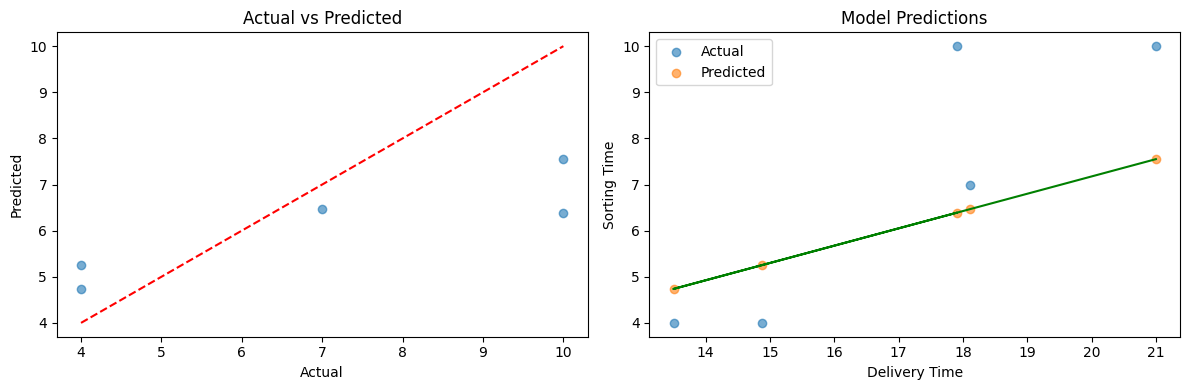

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(y1_test, y1_pred_test, alpha=0.6)
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

plt.subplot(1,2,2)
plt.scatter(X1_test, y1_test, alpha=0.6, label='Actual')
plt.scatter(X1_test, y1_pred_test, alpha=0.6, label='Predicted')
plt.plot(X1_test, y1_pred_test, color='green')
plt.xlabel('Delivery Time')
plt.ylabel('Sorting Time')
plt.legend()
plt.title('Model Predictions')

plt.tight_layout()
plt.show()

In [13]:
df2 = pd.read_csv('E:\\PGCP -BDA\\Machine_Learning\\Assignments\\Datasets\\NewspaperData.csv')
df2.head()

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093


In [14]:
df2.tail()

,Newspaper,daily,sunday
29,San Francisco Chronicle,570.364,704.322
30,St. Louis Post-Dispatch,391.286,585.681
31,St. Paul Pioneer Press,201.860,267.781
32,Tampa Tribune,321.626,408.343
33,Washington Post,838.902,1165.567


In [15]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Newspaper  34 non-null     object 
 1   daily      34 non-null     float64
 2   sunday     34 non-null     float64
dtypes: float64(2), object(1)
memory usage: 944.0+ bytes


In [16]:
df2.isna().sum()

Newspaper    0
daily        0
sunday       0
dtype: int64

In [17]:
df2.describe()

,daily,sunday
count,34.000000,34.000000
mean,430.962471,591.202412
std,269.211470,376.418051
min,133.239000,202.614000
25%,233.021500,327.769500
50%,355.235500,436.712500
75%,516.616500,699.735250
max,1209.225000,1762.015000


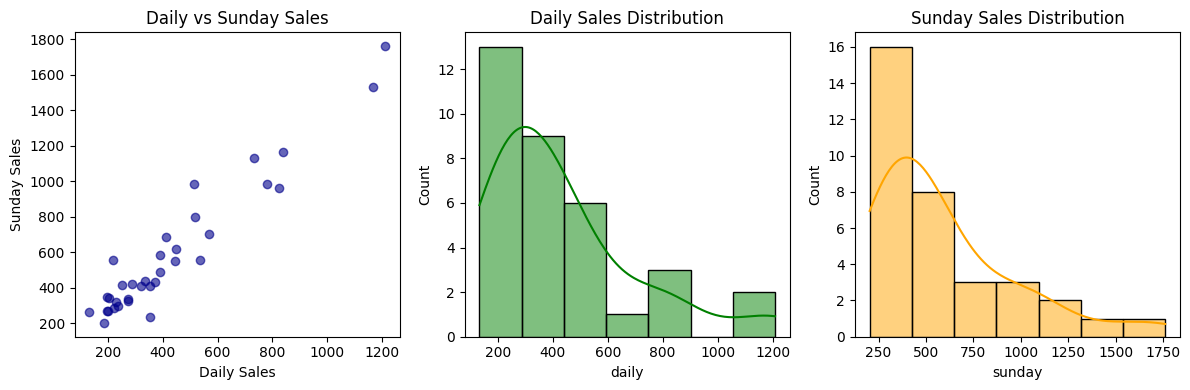

In [18]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(df2['daily'], df2['sunday'], alpha=0.6, color='darkblue')
plt.xlabel('Daily Sales')
plt.ylabel('Sunday Sales')
plt.title('Daily vs Sunday Sales')

plt.subplot(1,3,2)
sns.histplot(df2['daily'], kde=True, color='green')
plt.title('Daily Sales Distribution')

plt.subplot(1,3,3)
sns.histplot(df2['sunday'], kde=True, color='orange')
plt.title('Sunday Sales Distribution')

plt.tight_layout()
plt.show()

In [19]:
corr2 = df2['daily'].corr(df2['sunday'])
print(f'Correlation between Daily and Sunday Sales: {corr2:.3f}')

Correlation between Daily and Sunday Sales: 0.958


In [20]:
X2 = df2[['daily']]
y2 = df2['sunday']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [21]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print(f'Intercept: {model2.intercept_:.3f}')
print(f'Coefficient: {model2.coef_[0]:.3f}')
print(f'Equation: Sunday Sales = {model2.intercept_:.3f} + {model2.coef_[0]:.3f} * Daily Sales')

Intercept: -0.135
Coefficient: 1.380
Equation: Sunday Sales = -0.135 + 1.380 * Daily Sales


In [22]:
y2_pred_train = model2.predict(X2_train)
y2_pred_test = model2.predict(X2_test)

print('Training Set Performance:')
print(f'R² Score: {r2_score(y2_train, y2_pred_train):.4f}')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y2_train, y2_pred_train):.4f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y2_train, y2_pred_train)):.4f}')

print('\nTesting Set Performance:')
print(f'R² Score: {r2_score(y2_test, y2_pred_test):.4f}')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y2_test, y2_pred_test):.4f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y2_test, y2_pred_test)):.4f}')

Training Set Performance:
R² Score: 0.9255
Mean Absolute Error (MAE): 77.8708
Root Mean Squared Error (RMSE): 108.5063

Testing Set Performance:
R² Score: 0.7978
Mean Absolute Error (MAE): 89.0904
Root Mean Squared Error (RMSE): 99.6382


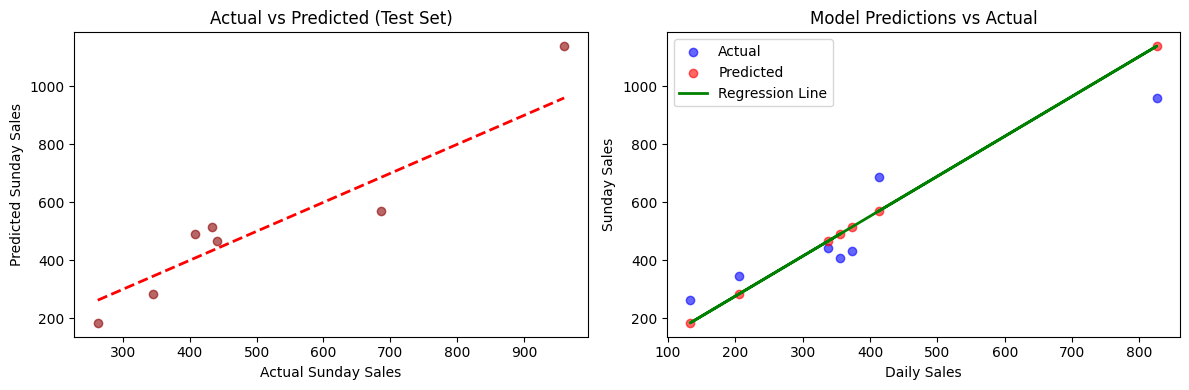

In [23]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(y2_test, y2_pred_test, alpha=0.6, color='darkred')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Sunday Sales')
plt.ylabel('Predicted Sunday Sales')
plt.title('Actual vs Predicted (Test Set)')

plt.subplot(1,2,2)
plt.scatter(X2_test, y2_test, alpha=0.6, color='blue', label='Actual')
plt.scatter(X2_test, y2_pred_test, alpha=0.6, color='red', label='Predicted')
plt.plot(X2_test, y2_pred_test, color='green', linewidth=2, label='Regression Line')
plt.xlabel('Daily Sales')
plt.ylabel('Sunday Sales')
plt.legend()
plt.title('Model Predictions vs Actual')

plt.tight_layout()
plt.show()

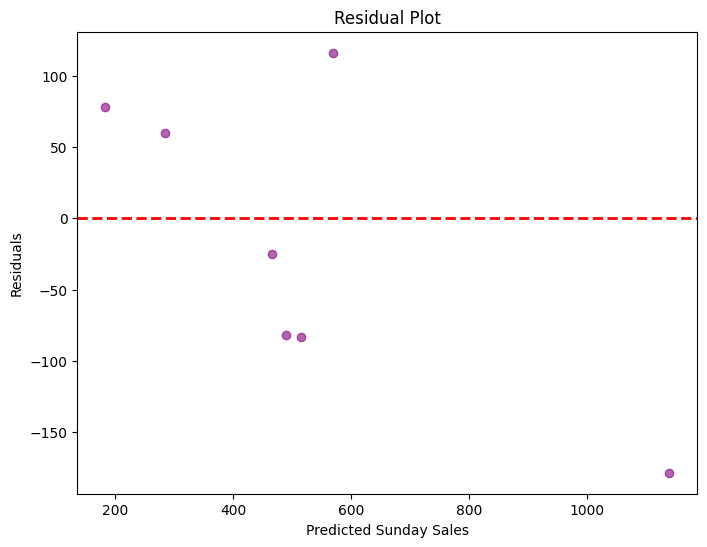

In [24]:
residuals2 = y2_test - y2_pred_test

plt.figure(figsize=(8,6))
plt.scatter(y2_pred_test, residuals2, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sunday Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

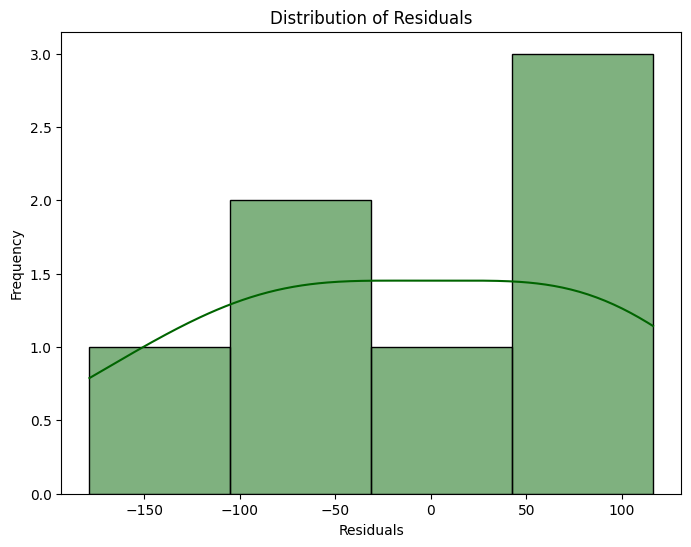

In [25]:
plt.figure(figsize=(8,6))
sns.histplot(residuals2, kde=True, color='darkgreen')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

In [26]:
df3 = pd.read_csv('E:\\PGCP -BDA\\Machine_Learning\\Assignments\\Datasets\\SAT-GPA.csv')
df3.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [27]:
df3.tail()

,SAT,GPA
79,1936,3.71
80,1810,3.71
81,1987,3.73
82,1962,3.76
83,2050,3.81


In [28]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     84 non-null     int64  
 1   GPA     84 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4 KB


In [29]:
df3.isna().sum()

SAT    0
GPA    0
dtype: int64

In [30]:
df3.describe()

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


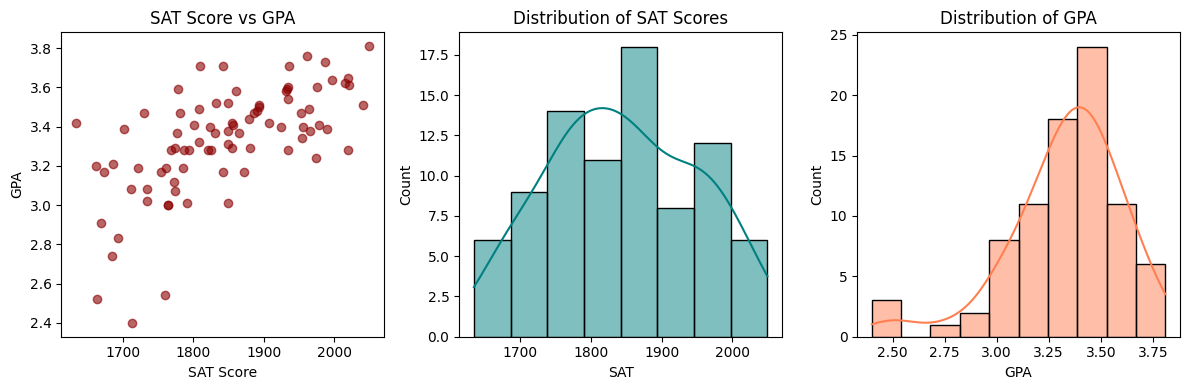

In [31]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(df3['SAT'], df3['GPA'], alpha=0.6, color='darkred')
plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.title('SAT Score vs GPA')

plt.subplot(1,3,2)
sns.histplot(df3['SAT'], kde=True, color='teal')
plt.title('Distribution of SAT Scores')

plt.subplot(1,3,3)
sns.histplot(df3['GPA'], kde=True, color='coral')
plt.title('Distribution of GPA')

plt.tight_layout()
plt.show()

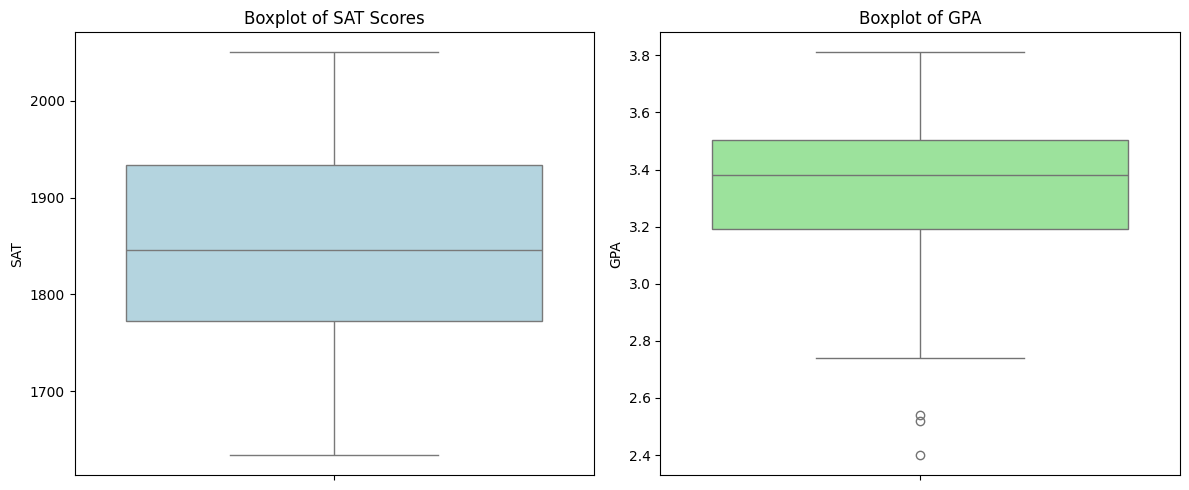

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df3['SAT'], color='lightblue')
plt.title('Boxplot of SAT Scores')

plt.subplot(1,2,2)
sns.boxplot(y=df3['GPA'], color='lightgreen')
plt.title('Boxplot of GPA')

plt.tight_layout()
plt.show()

In [33]:
corr3 = df3['SAT'].corr(df3['GPA'])
print(f'Correlation between SAT and GPA: {corr3:.3f}')

Correlation between SAT and GPA: 0.637


In [34]:
X3 = df3[['SAT']]
y3 = df3['GPA']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [35]:
model3 = LinearRegression()
model3.fit(X3_train, y3_train)

print(f'Intercept: {model3.intercept_:.4f}')
print(f'Coefficient: {model3.coef_[0]:.6f}')
print(f'Equation: GPA = {model3.intercept_:.4f} + {model3.coef_[0]:.6f} * SAT')

Intercept: 0.6259
Coefficient: 0.001469
Equation: GPA = 0.6259 + 0.001469 * SAT


In [36]:
y3_pred_train = model3.predict(X3_train)
y3_pred_test = model3.predict(X3_test)

print('Training Set Performance:')
print(f'R² Score: {r2_score(y3_train, y3_pred_train):.4f}')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y3_train, y3_pred_train):.4f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y3_train, y3_pred_train)):.4f}')

print('\nTesting Set Performance:')
print(f'R² Score: {r2_score(y3_test, y3_pred_test):.4f}')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y3_test, y3_pred_test):.4f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y3_test, y3_pred_test)):.4f}')

Training Set Performance:
R² Score: 0.3687
Mean Absolute Error (MAE): 0.1532
Root Mean Squared Error (RMSE): 0.2037

Testing Set Performance:
R² Score: 0.4695
Mean Absolute Error (MAE): 0.1627
Root Mean Squared Error (RMSE): 0.2291


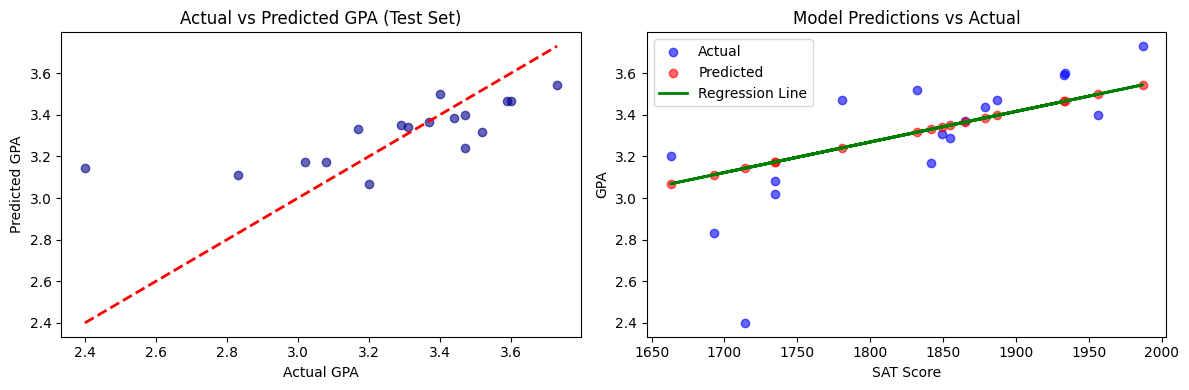

In [37]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(y3_test, y3_pred_test, alpha=0.6, color='darkblue')
plt.plot([y3_test.min(), y3_test.max()], [y3_test.min(), y3_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.title('Actual vs Predicted GPA (Test Set)')

plt.subplot(1,2,2)
plt.scatter(X3_test, y3_test, alpha=0.6, color='blue', label='Actual')
plt.scatter(X3_test, y3_pred_test, alpha=0.6, color='red', label='Predicted')
plt.plot(X3_test, y3_pred_test, color='green', linewidth=2, label='Regression Line')
plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.legend()
plt.title('Model Predictions vs Actual')

plt.tight_layout()
plt.show()

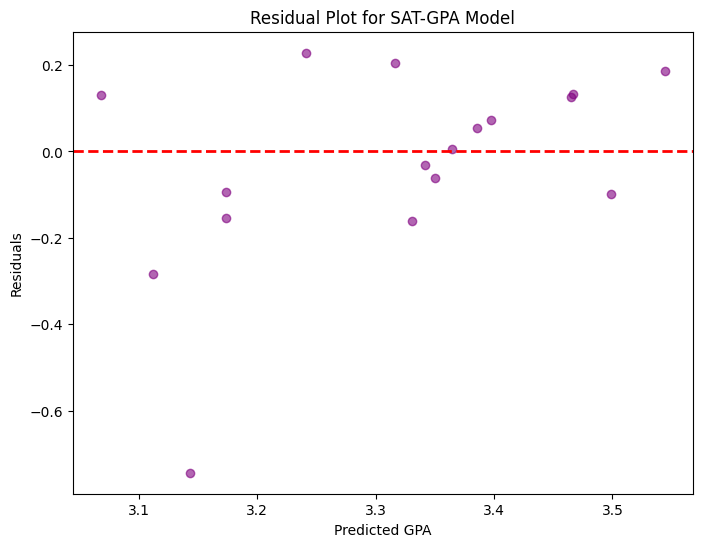

In [38]:
residuals3 = y3_test - y3_pred_test

plt.figure(figsize=(8,6))
plt.scatter(y3_pred_test, residuals3, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted GPA')
plt.ylabel('Residuals')
plt.title('Residual Plot for SAT-GPA Model')
plt.show()

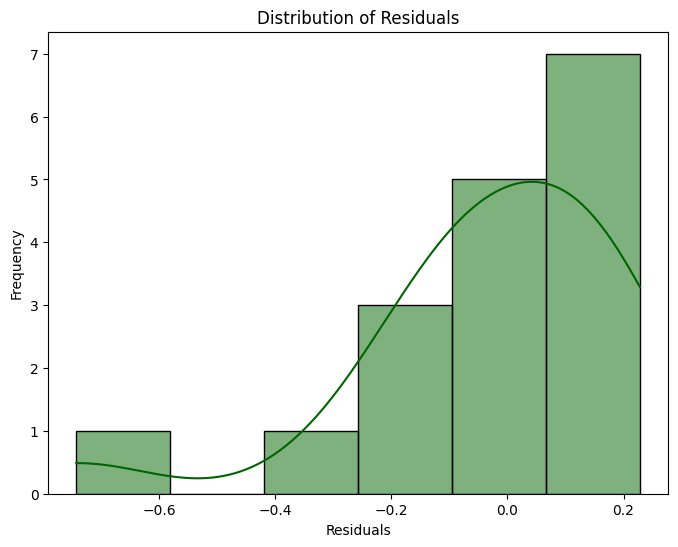

In [39]:
plt.figure(figsize=(8,6))
sns.histplot(residuals3, kde=True, color='darkgreen')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()